## Statistik Workflow of Moran Analysis Approach 1

In [1]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew
from scipy.stats import probplot
from scipy.stats import boxcox
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from rasterio.windows import Window

## Preprocessing of Data

In [2]:
# Set file path

iceslab_thickness_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped SW/Firnice_Thickness_SW_15km.shp"
#iceslab_thickness_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped CW/Firnice_Thickness_CW_15km.shp"
#iceslab_thickness_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped NW/Firnice_Thickness_NW_15km.shp"
#iceslab_thickness_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped NO/Firnice_Thickness_NO_15km.shp"
#iceslab_thickness_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Ice Slab (Jullien)/IceSlabs_20022018/IceSlabs_20022018/20102018/Ice_Thickness_Greenland_Firn/Clipped NE/Firnice_Thickness_NE_15km.shp"
hydrology_map_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/melting map/tedstone/master_hydrology_map_tedstone2022/master_map_GrIS_mean.vrt"
arctic_DEM = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/ArcticDEM/arcticdem_mosaic_100m_v4.1/arcticdem_mosaic_100m_v4.1_dem.tif"

# loading of data (rasterio for raster data --> hydrology map and DEM)
with rasterio.open(hydrology_map_path) as src:
    hydrology_map_crs = src.crs

with rasterio.open(arctic_DEM) as src:
    arctic_DEM_crs = src.crs

# While opening the file with geopandas, a new columne is created which has the POINT information about the coordinates.
iceslab_thickness = gpd.read_file(iceslab_thickness_path)
iceslab_thickness_crs = iceslab_thickness.crs

# if / else for comparison of both coordiante systems
if hydrology_map_crs != iceslab_thickness_crs != arctic_DEM_crs:
    print ("Not the same projection")
else:
    print ("Same projection")
    print ("CRS_hydromap:",  hydrology_map_crs)
    print ("CRS_iceslabs:",  iceslab_thickness_crs)
    print ("CRS_arcitc_DEM:", arctic_DEM_crs)

Same projection
CRS_hydromap: EPSG:3413
CRS_iceslabs: EPSG:3413
CRS_arcitc_DEM: EPSG:3413


In [3]:
#This code looks up all data points (coordinates from ice thickness data) on the hydrology map and calculates a buffer arround these points

iceslab_thickness = iceslab_thickness[iceslab_thickness.geometry.notnull()]

half_window = 3 #3 means that 7 x 7 pixels arround the exacte pixel are considered
#mean_values = []
max_values = []

with rasterio.open(hydrology_map_path) as src:
    height, width = src.height, src.width

    for pt in iceslab_thickness.geometry:
        x, y = pt.x, pt.y

        # coordinate --> rasterow and column
        row, col = src.index(x, y)

        # calculation of boundaries
        row_start = max(row - half_window, 0)
        col_start = max(col - half_window, 0)
        row_stop = min(row + half_window + 1, height)
        col_stop = min(col + half_window + 1, width)

        # calculation of area
        win_height = row_stop - row_start
        win_width = col_stop - col_start

        # area needs to be bigger than 1 x 1 pixel at least
        if win_height > 0 and win_width > 0:
            window = Window(col_start, row_start, win_width, win_height)
            data = src.read(1, window=window)
            #mean_val = np.mean(data) #Use this for mean and not max
            if np.all(np.isnan(data)): #Use this for max and not mean
                max_val = np.nan
            else:
                max_val = np.nanmax(data)
        else:
            max_val = None
            #mean_val = None

        #mean_values.append(mean_val)
        max_values.append(max_val)

# apply results to data
#iceslab_thickness["hydrology_value_buffer"] = mean_values
iceslab_thickness["hydrology_value_buffer"] = max_values
iceslab_thickness.to_csv("C:/Masterarbeit/Daten Masterarbeit/Outputs/inputbuffer_data.csv", index=False)
iceslab_thickness.head()

,field_1,Track_name,Tracenumbe,lat,lon,alongtrack,20m_ice_co,likelihood,geometry,hydrology_value_buffer
0,914,20100507_01_008_010,1070,67.963685,-47.502040,19021.45976,7.724075,0.935354,POINT (-105462.227 -2413510.49),55.716049
1,915,20100507_01_008_010,1071,67.963787,-47.501715,19039.33415,7.255949,0.976344,POINT (-105448.044 -2413499.612),54.679012
2,916,20100507_01_008_010,1072,67.963889,-47.501390,19057.20980,7.255949,0.956989,POINT (-105433.859 -2413488.733),54.679012
3,917,20100507_01_008_010,1073,67.963992,-47.501065,19075.08621,7.490012,0.962500,POINT (-105419.675 -2413477.854),54.679012
4,918,20100507_01_008_010,1074,67.964094,-47.500740,19092.96372,7.724075,0.987879,POINT (-105405.49 -2413466.973),54.493828


In [4]:
#Assigning different hihgts to the points according the DEM

with rasterio.open(arctic_DEM) as src:
    coords = [(point.x, point.y) for point in iceslab_thickness.geometry]
    elevation_values = [val[0] if val[0] is not None else None for val in src.sample(coords)]

iceslab_thickness["elevation_DEM"] = elevation_values

# Show table
iceslab_thickness.head()

,field_1,Track_name,Tracenumbe,lat,lon,alongtrack,20m_ice_co,likelihood,geometry,hydrology_value_buffer,elevation_DEM
0,914,20100507_01_008_010,1070,67.963685,-47.502040,19021.45976,7.724075,0.935354,POINT (-105462.227 -2413510.49),55.716049,1665.625000
1,915,20100507_01_008_010,1071,67.963787,-47.501715,19039.33415,7.255949,0.976344,POINT (-105448.044 -2413499.612),54.679012,1666.210938
2,916,20100507_01_008_010,1072,67.963889,-47.501390,19057.20980,7.255949,0.956989,POINT (-105433.859 -2413488.733),54.679012,1666.210938
3,917,20100507_01_008_010,1073,67.963992,-47.501065,19075.08621,7.490012,0.962500,POINT (-105419.675 -2413477.854),54.679012,1666.210938
4,918,20100507_01_008_010,1074,67.964094,-47.500740,19092.96372,7.724075,0.987879,POINT (-105405.49 -2413466.973),54.493828,1666.210938


In [5]:
# Handling of missing values. Check validity of measurements

print("Nummber of all data points:", len(iceslab_thickness))
print("Missing hydrology data:", iceslab_thickness["hydrology_value_buffer"].isna().sum()) #.isna is searching for the term NAN
print("Ice thickness values out of range (<0 or >20):", ((iceslab_thickness["20m_ice_co"] < 0) | (iceslab_thickness["20m_ice_co"] > 20)).sum())
print("Values smaller than 0 --> (NoData):", (iceslab_thickness["hydrology_value_buffer"] < 0).sum()) #searching for ice slab thickness values which are smaller than 0

Nummber of all data points: 206227
Missing hydrology data: 0
Ice thickness values out of range (<0 or >20): 0
Values smaller than 0 --> (NoData): 0


In [6]:
# Statistics of both values
hydro_mean = iceslab_thickness["hydrology_value_buffer"].mean()
ice_mean = iceslab_thickness["20m_ice_co"].mean()

print(round(hydro_mean, 3))
print(round(ice_mean, 3))

63.992
9.039


In [7]:
# Sort of the data (exclude all invalid data)

valid_iceslab_thickness = iceslab_thickness[
    (iceslab_thickness["hydrology_value_buffer"] > 0) &
    (iceslab_thickness["hydrology_value_buffer"] < 500)
]
# Number of valid data

valid_iceslab_thickness

,field_1,Track_name,Tracenumbe,lat,lon,alongtrack,20m_ice_co,likelihood,geometry,hydrology_value_buffer,elevation_DEM
0,914,20100507_01_008_010,1070,67.963685,-47.502040,19021.45976,7.724075,0.935354,POINT (-105462.227 -2413510.49),55.716049,1665.625000
1,915,20100507_01_008_010,1071,67.963787,-47.501715,19039.33415,7.255949,0.976344,POINT (-105448.044 -2413499.612),54.679012,1666.210938
2,916,20100507_01_008_010,1072,67.963889,-47.501390,19057.20980,7.255949,0.956989,POINT (-105433.859 -2413488.733),54.679012,1666.210938
3,917,20100507_01_008_010,1073,67.963992,-47.501065,19075.08621,7.490012,0.962500,POINT (-105419.675 -2413477.854),54.679012,1666.210938
4,918,20100507_01_008_010,1074,67.964094,-47.500740,19092.96372,7.724075,0.987879,POINT (-105405.49 -2413466.973),54.493828,1666.210938
...,...,...,...,...,...,...,...,...,...,...,...
206222,911494,20180429_01_008_014,11477,65.065653,-47.868185,135112.15660,13.482022,0.750617,POINT (-137245.29 -2739364.83),59.071430,2018.796875
206223,911495,20180429_01_008_014,11478,65.065548,-47.868157,135124.13450,13.981356,0.711905,POINT (-137244.523 -2739376.783),59.071430,2018.796875
206224,911496,20180429_01_008_014,11479,65.065443,-47.868128,135136.11270,15.479358,0.709677,POINT (-137243.756 -2739388.737),59.071430,2018.796875
206225,911497,20180429_01_008_014,11481,65.065233,-47.868071,135160.07000,15.978692,0.677083,POINT (-137242.225 -2739412.645),61.476189,2018.187500


In [8]:
# Sort of the data (assign elevation)

final_iceslab_thickness = valid_iceslab_thickness[
    (valid_iceslab_thickness["elevation_DEM"] >= 100) & 
    (valid_iceslab_thickness["elevation_DEM"] < 3000)
]
final_iceslab_thickness

,field_1,Track_name,Tracenumbe,lat,lon,alongtrack,20m_ice_co,likelihood,geometry,hydrology_value_buffer,elevation_DEM
0,914,20100507_01_008_010,1070,67.963685,-47.502040,19021.45976,7.724075,0.935354,POINT (-105462.227 -2413510.49),55.716049,1665.625000
1,915,20100507_01_008_010,1071,67.963787,-47.501715,19039.33415,7.255949,0.976344,POINT (-105448.044 -2413499.612),54.679012,1666.210938
2,916,20100507_01_008_010,1072,67.963889,-47.501390,19057.20980,7.255949,0.956989,POINT (-105433.859 -2413488.733),54.679012,1666.210938
3,917,20100507_01_008_010,1073,67.963992,-47.501065,19075.08621,7.490012,0.962500,POINT (-105419.675 -2413477.854),54.679012,1666.210938
4,918,20100507_01_008_010,1074,67.964094,-47.500740,19092.96372,7.724075,0.987879,POINT (-105405.49 -2413466.973),54.493828,1666.210938
...,...,...,...,...,...,...,...,...,...,...,...
206222,911494,20180429_01_008_014,11477,65.065653,-47.868185,135112.15660,13.482022,0.750617,POINT (-137245.29 -2739364.83),59.071430,2018.796875
206223,911495,20180429_01_008_014,11478,65.065548,-47.868157,135124.13450,13.981356,0.711905,POINT (-137244.523 -2739376.783),59.071430,2018.796875
206224,911496,20180429_01_008_014,11479,65.065443,-47.868128,135136.11270,15.479358,0.709677,POINT (-137243.756 -2739388.737),59.071430,2018.796875
206225,911497,20180429_01_008_014,11481,65.065233,-47.868071,135160.07000,15.978692,0.677083,POINT (-137242.225 -2739412.645),61.476189,2018.187500


## Part 1: Non spatial analysis

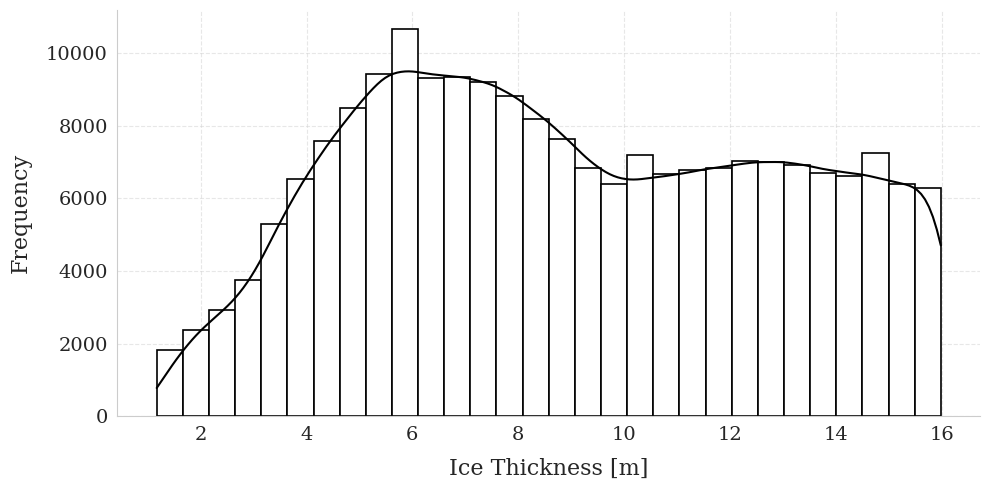

In [9]:
# Distribution of ice slab thickness data

# Definiton of plot style
plt.style.use('default') 
sns.set_style("whitegrid", {'axes.facecolor': 'white'})

# Assigning data
ice_data = final_iceslab_thickness["20m_ice_co"]

# Design-Setup
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
sns.histplot(ice_data, 
             bins=30, 
             kde=True, 
             fill=True,            
             color='white',        
             edgecolor='black',    
             linewidth=1.2,        
             #line_kws={'linewidth': 2, 'color': 'black', 'linestyle': '-'},
             alpha=1,              
             ax=ax)

# Colour of density curve
ax.lines[0].set_color('black')

# Raster and Frame
ax.grid(True, linestyle='--', alpha=0.5, color='#d1d1d1', zorder=0)
ax.set_axisbelow(True) # Raster hinter die Balken legen

# Labelling
#ax.set_title("SW", fontsize=15, pad=20)
ax.set_xlabel("Ice Thickness [m]", fontsize=16, labelpad=10)
ax.set_ylabel("Frequency", fontsize=16, labelpad=10)

# Ticks size
ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine()

plt.tight_layout()
# Saving of data
#plt.savefig("C:/Masterarbeit/Daten Masterarbeit/Outputs/QQ-Plots/SW.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
from scipy.stats import shapiro

# Shapiro-Wilk Test
sw_stat, sw_p = shapiro(final_iceslab_thickness["20m_ice_co"])
print(f"Shapiro-Wilk Test: Statistics={sw_stat:.3f}, p-value={sw_p:.3f}")

Shapiro-Wilk Test: Statistics=0.964, p-value=0.000


C:\Users\Marco Karrer\.conda\envs\pystac_example\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 206227.
  res = hypotest_fun_out(*samples, **kwds)


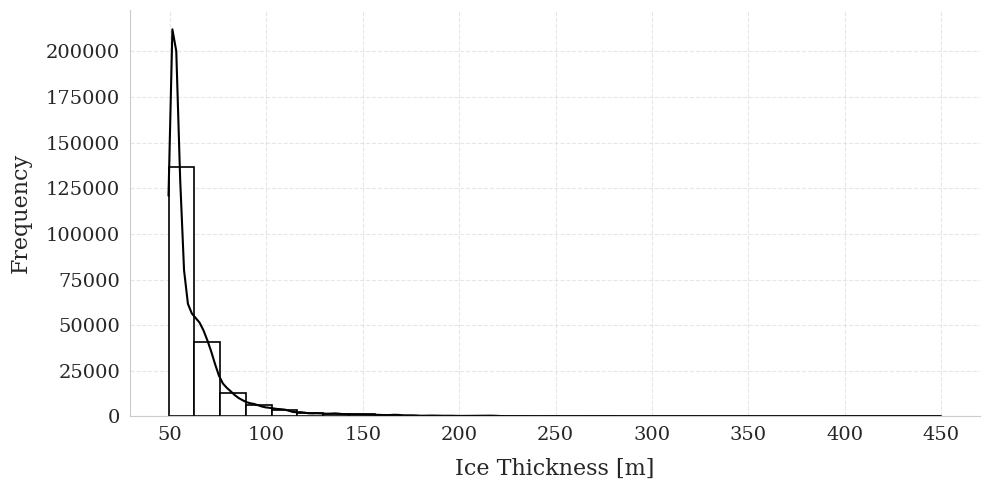

In [11]:
# Distribution of surface hydrology data

# Definiton of plot style
plt.style.use('default') 
sns.set_style("whitegrid", {'axes.facecolor': 'white'})

# Assigning data
ice_data = final_iceslab_thickness["hydrology_value_buffer"]

# Design-Setup
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
sns.histplot(ice_data, 
             bins=30, 
             kde=True, 
             fill=True,            
             color='white',        
             edgecolor='black',    
             linewidth=1.2,        
             #line_kws={'linewidth': 2, 'color': 'black', 'linestyle': '-'},
             alpha=1,              
             ax=ax)

# Colour of density curve
ax.lines[0].set_color('black')

# Raster and Frame
ax.grid(True, linestyle='--', alpha=0.5, color='#d1d1d1', zorder=0)
ax.set_axisbelow(True) # Raster hinter die Balken legen

# Labelling
#ax.set_title("SW", fontsize=15, pad=20)
ax.set_xlabel("Ice Thickness [m]", fontsize=16, labelpad=10)
ax.set_ylabel("Frequency", fontsize=16, labelpad=10)

# Ticks size
ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine()

plt.tight_layout()
# Saving of data
#plt.savefig("C:/Masterarbeit/Daten Masterarbeit/Outputs/QQ-Plots/SW.png", dpi=300, bbox_inches='tight')
plt.show()

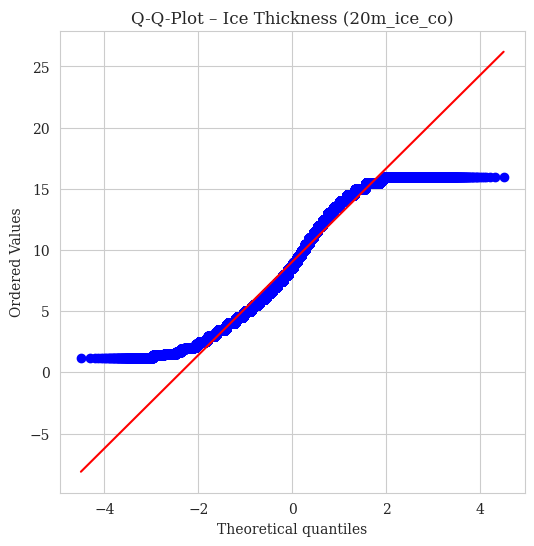

Skewness – Ice Thickness: 0.1


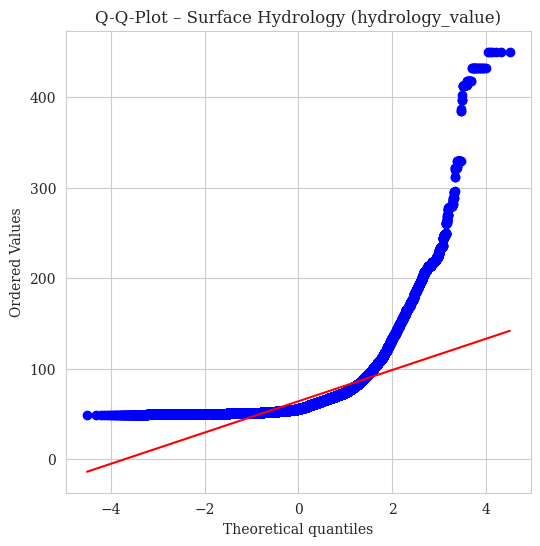

Skewness – Surface Hydrology: 4.49


In [12]:
# Q-Q Plots
# Columns
ice = final_iceslab_thickness["20m_ice_co"]
hydro = final_iceslab_thickness["hydrology_value_buffer"]

# Q-Q Plot Ice Thickness
plt.figure(figsize=(6, 6))
stats.probplot(ice, dist="norm", plot=plt)
plt.title("Q-Q-Plot – Ice Thickness (20m_ice_co)")
plt.show()

#Skewness of Ice Thickness
ice_skew = skew(ice)
print("Skewness – Ice Thickness:", round(ice_skew, 2))

#Q-Q Plot 
plt.figure(figsize=(6, 6))
stats.probplot(hydro, dist="norm", plot=plt)
plt.title("Q-Q-Plot – Surface Hydrology (hydrology_value)")
plt.show()

#Skewness of Surface Hydrology
hydro_skew = skew(hydro)
print("Skewness – Surface Hydrology:", round(hydro_skew, 2))

### Logarithmic transformation

In [13]:
# Log transformation of surface hydrology data

final_iceslab_thickness["hydrology_log"] = np.log(final_iceslab_thickness["hydrology_value_buffer"])

# capping at 95. percentile
upper_limit = final_iceslab_thickness["hydrology_log"].quantile(0.95)

# filtering for values smaller or same as 95. percentile
df_capped = final_iceslab_thickness[final_iceslab_thickness["hydrology_log"] <= upper_limit].copy()

# Skewness
capped_log_skew = skew(df_capped["hydrology_log"])
print("Skewness after log-transformation & capping:", round(capped_log_skew, 2))

Skewness after log-transformation & capping: 1.2


In [14]:
# Log transformation of ice thickness values

final_iceslab_thickness["ice_log"] = np.log1p(final_iceslab_thickness["20m_ice_co"])

# 2. Skewness-Vergleich berechnen
orig_skew = skew(final_iceslab_thickness["20m_ice_co"].dropna())
log_skew = skew(final_iceslab_thickness["ice_log"].dropna())

# Skewness
print("Skewness after log-transformation:", round(log_skew, 2))

Skewness after log-transformation & capping: -0.63


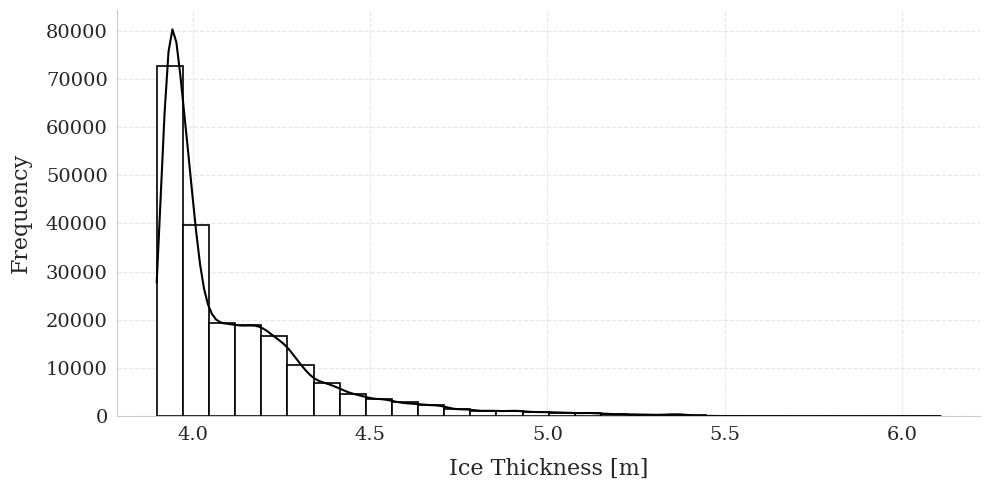

In [15]:
# Distribution Surface Hydrology after Log

# Definiton of plot style
plt.style.use('default') 
sns.set_style("whitegrid", {'axes.facecolor': 'white'})

# Assigning data
ice_data = final_iceslab_thickness["hydrology_log"]

# Design-Setup
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
sns.histplot(ice_data, 
             bins=30, 
             kde=True, 
             fill=True,            
             color='white',        
             edgecolor='black',    
             linewidth=1.2,        
             #line_kws={'linewidth': 2, 'color': 'black', 'linestyle': '-'},
             alpha=1,              
             ax=ax)

# Colour of density curve
ax.lines[0].set_color('black')

# Raster and Frame
ax.grid(True, linestyle='--', alpha=0.5, color='#d1d1d1', zorder=0)
ax.set_axisbelow(True) # Raster hinter die Balken legen

# Labelling
#ax.set_title("SW", fontsize=15, pad=20)
ax.set_xlabel("Ice Thickness [m]", fontsize=16, labelpad=10)
ax.set_ylabel("Frequency", fontsize=16, labelpad=10)

# Ticks size
ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine()

plt.tight_layout()
# Saving of data
#plt.savefig("C:/Masterarbeit/Daten Masterarbeit/Outputs/QQ-Plots/SW.png", dpi=300, bbox_inches='tight')
plt.show()

### Box-Cox

In [16]:
# Box-Cox transformation. The hydrology values are transformed woth boxcox() and saved under the name of hydrology_boxcox.
# Also the lambda is calculated. This value informs how big the transformation was.

# Preparring of data (For Boxcox all values must be above 0)
hydro_input = final_iceslab_thickness["hydrology_value_buffer"] + 0.00001

# Box-Cox transformation calculation
hydro_bc_raw, fitted_lambda = boxcox(hydro_input)

# calculation of 99. percentile
limit_bc_99 = np.quantile(hydro_bc_raw, 0.99)

# Clipping of data
final_iceslab_thickness["hydrology_boxcox"] = np.clip(hydro_bc_raw, None, limit_bc_99)

# Skewness
boxcox_skew = skew(final_iceslab_thickness["hydrology_boxcox"])
print("Skewness after Box-Cox transformation:", round(boxcox_skew, 2))
print("Optimal lambda (Box-Cox):", round(fitted_lambda, 3))

Skewness after Box-Cox transformation: 0.43
Optimal lambda (Box-Cox): -3.481


In [17]:
from scipy.stats import shapiro

# Shapiro-Wilk Test
sw_stat, sw_p = shapiro(final_iceslab_thickness["hydrology_boxcox"])
print(f"Shapiro-Wilk Test: Statistics={sw_stat:.3f}, p-value={sw_p:.3f}")

Shapiro-Wilk Test: Statistics=0.921, p-value=0.000


C:\Users\Marco Karrer\.conda\envs\pystac_example\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 206227.
  res = hypotest_fun_out(*samples, **kwds)


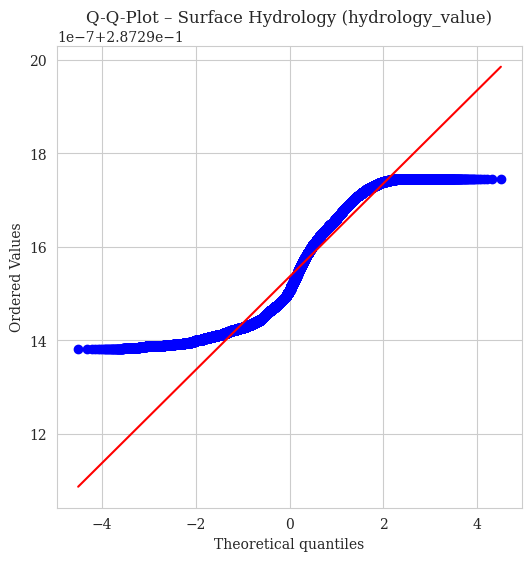

Skewness – Surface Hydrology: 0.43


In [18]:
hydro = final_iceslab_thickness["hydrology_boxcox"]

#Q-Q Plot 
plt.figure(figsize=(6, 6))
stats.probplot(hydro, dist="norm", plot=plt)
plt.title("Q-Q-Plot – Surface Hydrology (hydrology_value)")
plt.show()

#Skewness of Surface Hydrology
hydro_skew = skew(hydro)
print("Skewness – Surface Hydrology:", round(hydro_skew, 2))

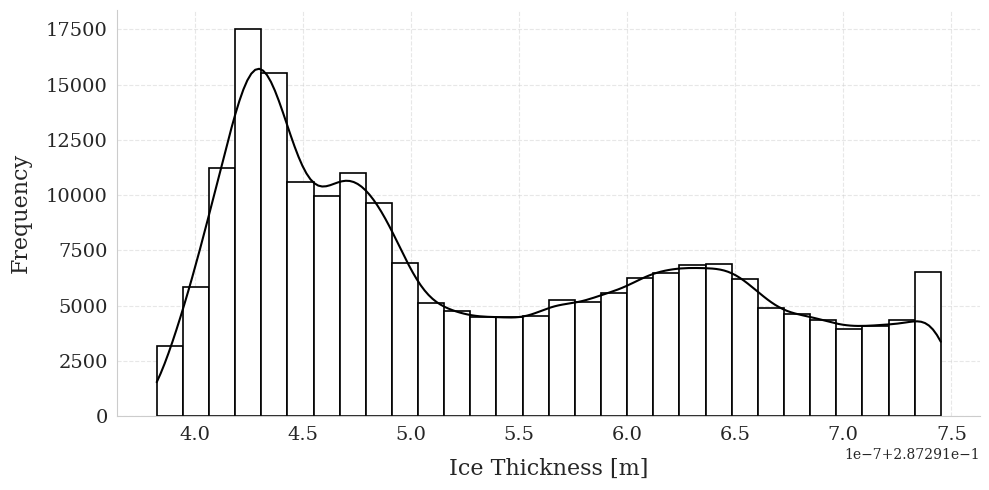

In [19]:
# Distribution Surface Hydrology after BoxCox

# Definiton of plot style
plt.style.use('default') 
sns.set_style("whitegrid", {'axes.facecolor': 'white'})

# Assigning data
ice_data = final_iceslab_thickness["hydrology_boxcox"]

# Design-Setup
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
sns.histplot(ice_data, 
             bins=30, 
             kde=True, 
             fill=True,            
             color='white',        
             edgecolor='black',    
             linewidth=1.2,        
             #line_kws={'linewidth': 2, 'color': 'black', 'linestyle': '-'},
             alpha=1,              
             ax=ax)

# Colour of density curve
ax.lines[0].set_color('black')

# Raster and Frame
ax.grid(True, linestyle='--', alpha=0.5, color='#d1d1d1', zorder=0)
ax.set_axisbelow(True) # Raster hinter die Balken legen

# Labelling
#ax.set_title("SW", fontsize=15, pad=20)
ax.set_xlabel("Ice Thickness [m]", fontsize=16, labelpad=10)
ax.set_ylabel("Frequency", fontsize=16, labelpad=10)

# Ticks size
ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine()

plt.tight_layout()
# Saving of data
#plt.savefig("C:/Masterarbeit/Daten Masterarbeit/Outputs/QQ-Plots/SW.png", dpi=300, bbox_inches='tight')
plt.show()

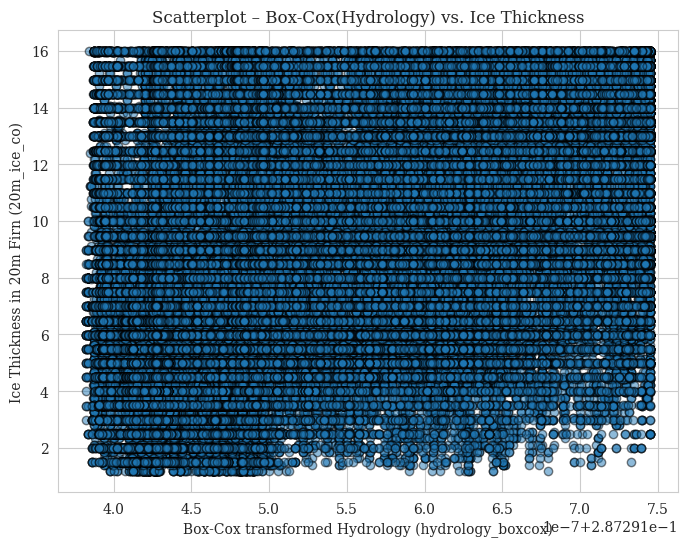

In [20]:
# Scatterplot: Ice Thickness vs. Surface Hydrology after Box-Cox-transformation
plt.figure(figsize=(8, 6))
#plt.scatter(final_iceslab_thickness["hydrology_log"], valid_iceslab_thickness["20m_ice_co"], alpha=0.5, edgecolors="k")
plt.scatter(final_iceslab_thickness["hydrology_boxcox"], final_iceslab_thickness["20m_ice_co"], alpha=0.5, edgecolors="k")
plt.title("Scatterplot – Box-Cox(Hydrology) vs. Ice Thickness")
plt.xlabel("Box-Cox transformed Hydrology (hydrology_boxcox)")
plt.ylabel("Ice Thickness in 20m Firn (20m_ice_co)")
plt.grid(True)
plt.show()

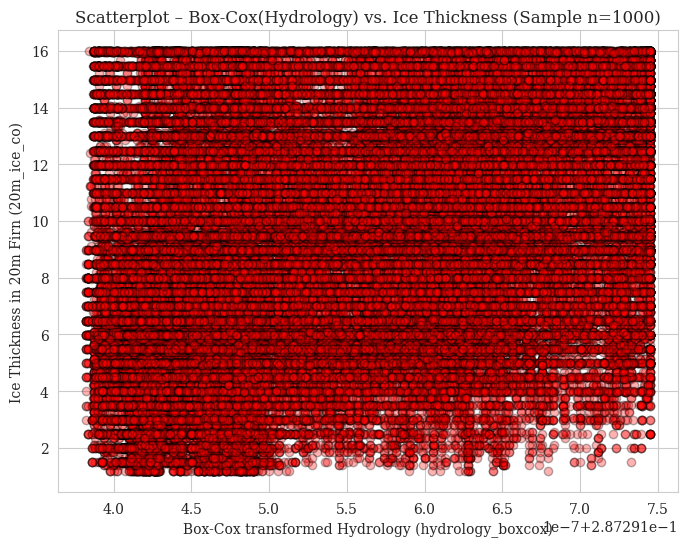

In [21]:
# Random choosing of a datasample set (used if many data and calculation for moran takes to long)
sample_greenlanddata = final_iceslab_thickness.sample(206227, random_state=1) # random_state=1 always choose the same sample

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(
    #sample_greenlanddata["hydrology_log"],
    sample_greenlanddata["hydrology_boxcox"],
    sample_greenlanddata["20m_ice_co"],
    #sample_greenlanddata["ice_log"],
    alpha=0.3,
    edgecolors="k",
    color="red"
)
plt.title("Scatterplot – Box-Cox(Hydrology) vs. Ice Thickness (Sample n=1000)")
plt.xlabel("Box-Cox transformed Hydrology (hydrology_boxcox)")
plt.ylabel("Ice Thickness in 20m Firn (20m_ice_co)") 
plt.grid(True)
plt.show()


### Spearman and Pearson



In [22]:
# load columns
x = sample_greenlanddata["20m_ice_co"] 
y = sample_greenlanddata["hydrology_boxcox"]

# Definiton of significance
def get_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return " (n.s.)"

# Pearson-Correlation
pearson_corr, pearson_p = pearsonr(x, y)
print(f"Pearson-Correlation:  {round(pearson_corr, 3):<6} | p-value: {round(pearson_p, 3):<6} {get_stars(pearson_p)}")

# Spearman-Correlation
spearman_corr, spearman_p = spearmanr(x, y)
print(f"Spearman-Correlation: {round(spearman_corr, 3):<6} | p-value: {round(spearman_p, 3):<6} {get_stars(spearman_p)}")

Pearson-Correlation:  0.416  | p-value: 0.0    ***
Spearman-Correlation: 0.423  | p-value: 0.0    ***


In [23]:
# Some statisitcs after Non spatial analysis

ice_mean = sample_greenlanddata["20m_ice_co"].mean()
hydro_mean = sample_greenlanddata["hydrology_value_buffer"].mean()
boxcox_mean = sample_greenlanddata["hydrology_boxcox"].mean()
ice_std = sample_greenlanddata["20m_ice_co"].std()
boxcox_std = sample_greenlanddata["hydrology_boxcox"].std()

print("Mean Ice Thickness (20m_ice_co):", round(ice_mean, 4))
print("Mean Hydrology:", round(hydro_mean, 8))
print("Mean Hydrology (BoxCox):", round(boxcox_mean, 8))
print("Std Ice Thickness (20m_ice_co):", round(ice_std, 4))
print("Std Hydrology (BoxCox):", round(boxcox_std, 8))

Mean Ice Thickness (20m_ice_co): 9.0386
Mean Hydrology: 63.992306
Mean Hydrology (BoxCox): 0.28729154
Std Ice Thickness (20m_ice_co): 3.8815
Std Hydrology (BoxCox): 1e-07


## Part 2: Spatial analysis

In [24]:
import libpysal
from esda.moran import Moran_BV
from esda.moran import Moran_Local_BV

### Global Bivariate Moran's Test

The global bavariate morans test, tests if there is a spatial autocorrelation between two variables.

In [25]:
# Definition of significance
def get_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return " (n.s.)"

# Spatial Weights Matrix (k-nearest neighbors) and R for Row-standardization
# Coordinates for each point of the chosen sample are extracted
coords = np.array([(geom.x, geom.y) for geom in sample_greenlanddata.geometry]) 
knn = libpysal.weights.KNN.from_array(coords, k=12)
knn.transform = 'R'

# Definition of variables (x: target, y: neighbour)
x = sample_greenlanddata["20m_ice_co"].values
y = sample_greenlanddata["hydrology_boxcox"].values

# Global bivariate Moran's test
moran_bv = Moran_BV(x, y, knn, permutations = 999)

# Statistics
z_score = (moran_bv.I - moran_bv.EI_sim) / np.sqrt(moran_bv.VI_sim)
p_value = moran_bv.p_sim
stars = get_stars(p_value)

# Results of statistic
print(f"Global Bivariate Moran's Test: {round(moran_bv.I, 4)} {stars}")
print(f"p-Value (permutation test):    {p_value:.8f}")
print(f"Z-Score:                      {round(z_score, 3)}")

C:\Users\Marco Karrer\.conda\envs\pystac_example\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 56 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Global Bivariate Moran's Test: 0.4156 **
p-Value (permutation test):    0.00100000
Z-Score:                      209.568


### Local Bivariate Moran's Test

C:\Users\Marco Karrer\.conda\envs\pystac_example\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 38 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


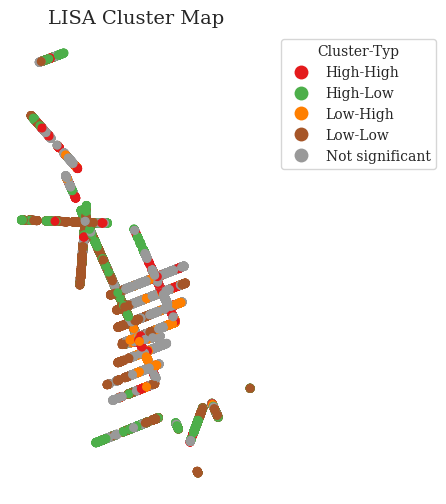

In [177]:
import numpy as np
# extract coordinates
coords = np.array([(point.x, point.y) for point in sample_greenlanddata.geometry])

# generate a neighborhood matrix with 12 neighbours
knn = libpysal.weights.KNN.from_array(coords, k=12)
knn.transform = 'R'

# definition of variables (x: target, y: neighbour)
x = sample_greenlanddata["20m_ice_co"].values  
y = sample_greenlanddata["hydrology_boxcox"].values 

# locale bivariat Moran's test
local_moran_bv = Moran_Local_BV(x, y, knn)

# save the two values I and p to my data
sample_greenlanddata["LISA_BV_I"] = local_moran_bv.Is
sample_greenlanddata["LISA_BV_p"] = local_moran_bv.p_sim

# Cluster-Typ classification --> first, everything is classified as not significant
sample_greenlanddata["LISA_BV_cluster"] = "Not significant"
significant = local_moran_bv.p_sim < 0.05 #looking for values with smaller p-values than 0.05 to classifie as significant

#assignign of different classes 
#(PySAL default quadrant definition: HH=1, LH=2, LL=3, HL=4)
quadrant_labels = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
sample_greenlanddata.loc[significant, "LISA_BV_cluster"] = [
    quadrant_labels[q] for q in local_moran_bv.q[significant]
]

# Mean local Bivariate I value
mean_i_all = sample_greenlanddata["LISA_BV_I"].mean()
print(mean_i_all)

#generates a plot to visualize the output
fig, ax = plt.subplots(figsize=(8, 6))
sample_greenlanddata.plot(
    column="LISA_BV_cluster",
    cmap="Set1",
    legend=True,
    markersize=30,
    ax=ax,
    legend_kwds={
        'loc': 'upper left',
        'bbox_to_anchor': (1.05, 1),
        'title': "Cluster-Typ"
    }
)

plt.title("LISA Cluster Map", fontsize=14)
plt.axis("off")

#save as pdf and gpkg to open in qgis
#sample_greenlanddata.to_file("C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach1/Icethickness_ClusterMap_NE_15km.gpkg",
               #layer="ice_thickness",
               #driver="GPKG")
plt.show()